# Lab: Nonlinearities
## CMSE 381 - Spring 2022
## March 25, 2022



##ANSWER## 

*Instructor notes:*

Made use of these python translations
- [Poly regression, step functions](https://www.science.smith.edu/~jcrouser/SDS293/labs/lab12-py.html)
- [Splines lab](https://www.science.smith.edu/~jcrouser/SDS293/labs/lab13-py.html)

Got the data [here](https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/master/Notebooks/Data/Wage.csv)

**Liz notes March 2022**

Holy monkeys that was too long. Maybe I didn't scaffold enough, but they were CONFUSED. Most groups got through polynomial regression, at best the step function.  I saw one group looking at the spline but didn't seem like they were really working through it.

In rewrite, the goal should be to emphasize "We make feature matrix, we pass to linear regression without having to tell it that there's anything special going on".  Probably focus should just be on poly and step function then.  Maybe splines if they really wanna, but that feels like it should be its own beast. Also, part of the issue seems to be the fact that the pattern wasn't obvious from the code inputs, so that can be emphasized on rewrite.

The part with GLMs should be ditched. That's based on someone's open source codebank that doesn't seem to have been maintained since 2018 and comes with warnings about known bugs that aren't getting fixed any time soon. Again, maybe just emphasizing that all we're doing is making a new feature matrix with now even more functions and passing it to the linear regression model should be the order of the day


In this module we are going to test out the nonlinear methods we discussed in class from Chapter 7.

In [3]:
# Everyone's favorite standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import time


# ML imports we've used previously
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import statsmodels.api as sm


# Loading in the data

We're going to use the `Wage` data used in the book, so note that many of your plots can be checked by looking at figures in the book.

In [4]:
df = pd.read_csv('Wage.csv', index_col =0 )
df.head()

,year,age,sex,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
231655,2006,18,1. Male,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
86582,2004,24,1. Male,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
161300,2003,45,1. Male,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
155159,2003,43,1. Male,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
11443,2005,50,1. Male,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3000 entries, 231655 to 453557
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year        3000 non-null   int64  
 1   age         3000 non-null   int64  
 2   sex         3000 non-null   object 
 3   maritl      3000 non-null   object 
 4   race        3000 non-null   object 
 5   education   3000 non-null   object 
 6   region      3000 non-null   object 
 7   jobclass    3000 non-null   object 
 8   health      3000 non-null   object 
 9   health_ins  3000 non-null   object 
 10  logwage     3000 non-null   float64
 11  wage        3000 non-null   float64
dtypes: float64(2), int64(2), object(8)
memory usage: 304.7+ KB


In [6]:
df.describe()

,year,age,logwage,wage
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2005.791000,42.414667,4.653905,111.703608
std,2.026167,11.542406,0.351753,41.728595
min,2003.000000,18.000000,3.000000,20.085537
25%,2004.000000,33.750000,4.447158,85.383940
50%,2006.000000,42.000000,4.653213,104.921507
75%,2008.000000,51.000000,4.857332,128.680488
max,2009.000000,80.000000,5.763128,318.342430


Here's the plot we used multiple times in class to look at a single variable:  `age` vs `wage`

Text(0, 0.5, 'Wage')

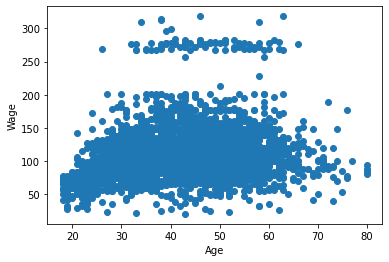

In [7]:
plt.scatter(df.age,df.wage)
plt.xlabel('Age')
plt.ylabel('Wage')

&#9989; **<font color=red>Do this:</font>** Modify the plot above so that the people earning above 250 are in a different color and/or symbol set.




In [8]:
# Your code here 

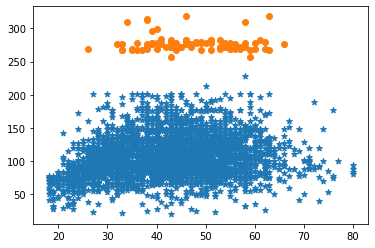

In [9]:
##ANSWER##

plt.scatter(df.age[df.wage <=250], df.wage[df.wage<=250],marker = '*')
plt.scatter(df.age[df.wage >250], df.wage[df.wage>250])


# 1a. Polynomial Regression 

Our first step is to build a polynomial regression model using the age data to predict wage.  So, as in class, we are in $p=1$ world here where we are going to fit the model
$$
\texttt{wage} = \beta_0 + \beta_1 \texttt{age} + \beta_2 \texttt{age}^2 + \cdots + \beta_p \texttt{age}^p +\varepsilon.
$$

The trick here is to build a matrix $X$ which has a column containing `age`, one with `age^2`, one with `age^3`, etc.  Then we hand this to your favorite regression tool (it doesn't need to know it's getting polynomial matrix inputs, it just sees a matrix of features and does it's thing). 

So, here's some code to take our $\texttt{age}$ data column and create a bunch of new columns in our data frame that are simply each the $k$th power of the `age` column

In [10]:
# Here's the column I care about
df.age

231655    18
86582     24
161300    45
155159    43
11443     50
          ..
376816    44
302281    30
10033     27
14375     27
453557    55
Name: age, Length: 3000, dtype: int64

In [11]:
# Here's one way to get out the pandas series that squares
# each entry
df.age.apply(lambda x: x**2)

231655     324
86582      576
161300    2025
155159    1849
11443     2500
          ... 
376816    1936
302281     900
10033      729
14375      729
453557    3025
Name: age, Length: 3000, dtype: int64

&#9989; **<font color=red>Do this:</font>** Use the code above (or any other tricks you might know) to generate a data frame called `polydf` with 4 columns, where the $k$th column has $\texttt{age}^k$




In [12]:
# Your code here #

In [13]:
##ANSWER##

data = {'age'+str(k) : df.age.apply(lambda x: x**k) for k in (1,2,3,4)}

polydf = pd.DataFrame(data)

polydf

,age1,age2,age3,age4
231655,18,324,5832,104976
86582,24,576,13824,331776
161300,45,2025,91125,4100625
155159,43,1849,79507,3418801
11443,50,2500,125000,6250000
...,...,...,...,...
376816,44,1936,85184,3748096
302281,30,900,27000,810000
10033,27,729,19683,531441
14375,27,729,19683,531441


Did I need to make you do that? It turns out no. As with many things we've talked about in class, there is already some automated code for us to work with.  In this case, the only difference is that it will hand us back a matrix rather than a data frame. 

In [14]:
from sklearn.preprocessing import PolynomialFeatures

In [15]:
poly = PolynomialFeatures(4)
X = poly.fit_transform(df.age.values.reshape(-1,1)) #<--- this nastyness is because it wants to be handed a matrix
X[:10,:]

array([[1.000000e+00, 1.800000e+01, 3.240000e+02, 5.832000e+03,
        1.049760e+05],
       [1.000000e+00, 2.400000e+01, 5.760000e+02, 1.382400e+04,
        3.317760e+05],
       [1.000000e+00, 4.500000e+01, 2.025000e+03, 9.112500e+04,
        4.100625e+06],
       [1.000000e+00, 4.300000e+01, 1.849000e+03, 7.950700e+04,
        3.418801e+06],
       [1.000000e+00, 5.000000e+01, 2.500000e+03, 1.250000e+05,
        6.250000e+06],
       [1.000000e+00, 5.400000e+01, 2.916000e+03, 1.574640e+05,
        8.503056e+06],
       [1.000000e+00, 4.400000e+01, 1.936000e+03, 8.518400e+04,
        3.748096e+06],
       [1.000000e+00, 3.000000e+01, 9.000000e+02, 2.700000e+04,
        8.100000e+05],
       [1.000000e+00, 4.100000e+01, 1.681000e+03, 6.892100e+04,
        2.825761e+06],
       [1.000000e+00, 5.200000e+01, 2.704000e+03, 1.406080e+05,
        7.311616e+06]])

&#9989; **<font color=red>Q:</font>** What other major difference do you notice between the dataframe you constructed above and the matrix provided here? Why do you think that is happening?

*Your answer here*





##ANSWER## 

That first column is entirely 1's. It's basically what happens when you take $x^0$ power and is useful for doing some of these tricks with matrix multiplication to get the coefficients. 

In [16]:
# Your code here #

&#9989; **<font color=red>Do this:</font>** Train a linear regression model on these features. What are the coefficients? 


In [17]:
# Your code here #

In [18]:
##ANSWER##
from sklearn.linear_model import LinearRegression

reg = LinearRegression().fit(X,df.wage)
print(reg.coef_)
print(reg.intercept_)

[ 0.00000000e+00  2.12455205e+01 -5.63859313e-01  6.81068771e-03
 -3.20383038e-05]
-184.1541797523223


&#9989; **<font color=red>Q:</font>** What is the equation for the polynomial that you learned? 

*Your equation here*

&#9989; **<font color=red>Do this:</font>** Draw the polynomial that you learned on top of the age vs wage plot (basically, reconstruct the left side of Fig 7.1 of the textbook, without dealing with the confidence intervals). Note that you can either do this using the polynomial you just figured out, or by using the model you just set up to predict the values. In either case, use the vector of ages `t` below.

In [19]:
# Your code here #
t = np.linspace(10,100,100)

In [20]:
##ANSWER## 
t = np.linspace(10,100,100)

# Plan A: 
vals = np.array([t**k*reg.coef_[k] for k in [1,2,3,4]])
p = reg.intercept_ + vals.sum(axis= 0)

# Plan B:
T = poly.fit_transform(t.reshape(-1,1))
p = reg.predict(T)

Text(0, 0.5, 'Wage')

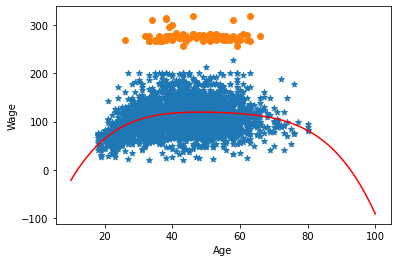

In [21]:
##ANSWER##
plt.scatter(df.age[df.wage <=250], df.wage[df.wage<=250],marker = '*')
plt.scatter(df.age[df.wage >250], df.wage[df.wage>250])

plt.plot(t,p, c= 'red')
plt.xlabel('Age')
plt.ylabel('Wage')

## Classification version 

Now we can try out the classification version of the problem. Let's build the classifier that predicts whether a person of a given age will make more than $250,000. You already made the matrix of polynomial features, so we just have to hand it to `LogisticRegression` to do its thing.

In [22]:
from sklearn.linear_model import LogisticRegression

In [23]:
y = np.array(df.wage>250) #<--- this makes sure I just have true/false input
clf = LogisticRegression(random_state=48824)
clf.fit(X,y)

LogisticRegression(random_state=48824)

&#9989; **<font color=red>Do this:</font>** Use the model to predict whether or not a person with age given by each entry in your `t` array from above makes above $250K.  Does your result make sense given the right side of Fig 7.1 in the book?


In [24]:
# Your code here #

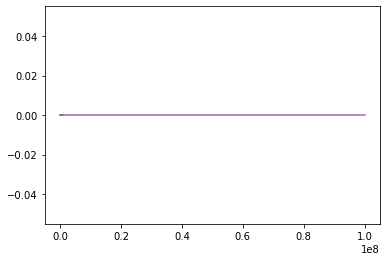

In [25]:
##ANSWER## 
T = poly.fit_transform(t.reshape(-1,1))

ageFunc = clf.predict(T)
plt.plot(T,ageFunc)

# Note that EVERYONE is predicted to be no. 
# This makes sense with the fig cuz the probabilities are
# what are graphed, and checking the y-axis
# we see that the probabilities we're talking about 
# are super low. So no one is ever predicted to make
# above 250 just given their age. 

Now we'll try to actually recreate Fig 7.1.  

*Note: We should be able to do this with `scikit-learn`, however when I do that, I'm not getting the same function shown in the book and I don't know why.  For now, we'll go over to the stats model package to draw until I can understand why the outputs I'm getting aren't the same.*

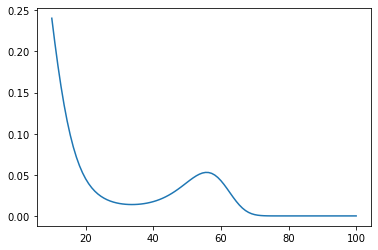

In [26]:
##ANSWER## 
# This should be the same and I don't know why

# Update: Seems to be related to the 
# family=sm.families.Binomial(sm.families.links.logit)
# part of the input below, but i don't know where that 
# shows up in scikit learn
T = poly.fit_transform(t.reshape(-1,1))

ageFunc = clf.predict_proba(T)
plt.plot(t,ageFunc[:,1])

Text(0, 0.5, 'Pr(wage>250|age)')

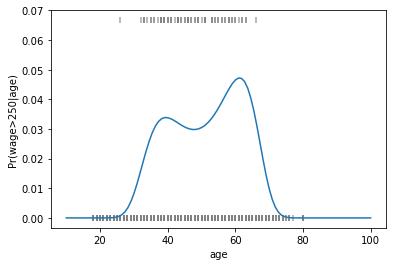

In [27]:
# This part fits our model using statsmodel
clf = sm.GLM(y, X, family=sm.families.Binomial(sm.families.links.logit()))
res = clf.fit()
pred2 = res.predict(T)  # Pr(wage>250)

# This part plots the probability distribution
plt.plot(t,pred2)

# What is this doing?
plt.scatter(df.age, y/15, s=30, c='grey', marker='|', alpha=0.7)

plt.xlabel('age')
plt.ylabel('Pr(wage>250|age)')

&#9989; **<font color=red>Q:</font>** What is that scatter plot command doing above?

*Your answer here*

# 1b. Step functions

Now let's try to use step functions to learn a model. Like with the polynomial example above, all we're going to do is build a data frame or feature matrix that has the step function values in each column, and then pass that matrix to our favorite linear modeling function. 

First off, it's easy to find the locations for the knots, which are the places where we switch step functions. Here's the pandas `cut` command, which in this case on some toy data, gives me 3 equal-sized bins, where here, equal-sized means that the width of the intervals are all the same.

In [28]:
fakeData = np.array([1, 7, 3, 5, 4, 6, 3, 3 , 6,2])
cuts, knots = pd.cut(fakeData, 3,retbins=True)
print(cuts)
print(knots)

[(0.994, 3.0], (5.0, 7.0], (0.994, 3.0], (3.0, 5.0], (3.0, 5.0], (5.0, 7.0], (0.994, 3.0], (0.994, 3.0], (5.0, 7.0], (0.994, 3.0]]
Categories (3, interval[float64]): [(0.994, 3.0] < (3.0, 5.0] < (5.0, 7.0]]
[0.994 3.    5.    7.   ]


The `retbins=True` tells the command to return the breakpoints in the bins, which I saved in my output as `knots`. 

We can either see the intervals chosen by looking at the `categories` saved to the cuts, or by looking at the knots list. 

In [29]:
print(cuts.categories)
print(knots)

IntervalIndex([(0.994, 3.0], (3.0, 5.0], (5.0, 7.0]],
              closed='right',
              dtype='interval[float64]')
[0.994 3.    5.    7.   ]


I can find out what bin the $i$th entry is mapped to by just checking the cuts list. 

In [30]:
i = 5
print('Entry is:', fakeData[i])
print('This comes from bin:', cuts[i])

Entry is: 6
This comes from bin: (5.0, 7.0]


We can also see how many data points ended up in each interval.

In [31]:
cuts.value_counts()

(0.994, 3.0]    5
(3.0, 5.0]      2
(5.0, 7.0]      3
dtype: int64

Once we've got this list of bins, we can build the data frame that keeps track of all the true/false values for whether a data point is in a particular interval by using the dummy variable trick. 

In [32]:
pd.get_dummies(cuts)

,"(0.994, 3.0]","(3.0, 5.0]","(5.0, 7.0]"
0,1,0,0
1,0,0,1
2,1,0,0
3,0,1,0
4,0,1,0
5,0,0,1
6,1,0,0
7,1,0,0
8,0,0,1
9,1,0,0


Then, if I want to figure out which bin is assigned for some other matrix of values that I want to test, I can use the `np.digitize` function as follows.

In [33]:
u = np.linspace(0,10,12)
print(u)
np.digitize(u,knots)

[ 0.          0.90909091  1.81818182  2.72727273  3.63636364  4.54545455
  5.45454545  6.36363636  7.27272727  8.18181818  9.09090909 10.        ]


array([0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 4, 4])

&#9989; **<font color=red>Q:</font>** What do the entries 0 and 4 correspond to in the output above?

*Your answer here* 

##ANSWER##

0 is the values that are in the bin (-$\infty$,first entry]. In my case, I have knots:

```[0.994 3.    5.    7.   ]```

so 0 corresponds to values <0.994. 
Likewise, 4 corresponds to (last entry,$\infty$), so anything >7.


&#9989; **<font color=red>Do this:</font>**
- Use the `cut` tool above to create a feature matrix for the `age` data where each column corresponds to a step function using 4 bins. 
- Drop the first bin.... remember we don't need all of our dummy variables, so we'll just use the remaining 3 to predict.
- Pass this matrix to a linear regression model. 
- Using your model, predict the values on the original $t$ matrix from before.
- Plot the predictions on top of the original sampled data.

*Note: If all goes well, you should have a graph that looks like the right side of Fig 7.2*

In [34]:
# Your code here #

In [35]:
##ANSWER##
df_cut, bins = pd.cut(df.age, 4, retbins = True, right = True)
df_cut.value_counts(sort = False)
df_steps_dummies = pd.get_dummies(df_cut)

df_steps_dummies

,"(17.938, 33.5]","(33.5, 49.0]","(49.0, 64.5]","(64.5, 80.0]"
231655,1,0,0,0
86582,1,0,0,0
161300,0,1,0,0
155159,0,1,0,0
11443,0,0,1,0
...,...,...,...,...
376816,0,1,0,0
302281,1,0,0,0
10033,1,0,0,0
14375,1,0,0,0


In [36]:
##ANSWER## 
print(df_steps_dummies.columns[0])
df_steps_dummies = df_steps_dummies.drop(columns = df_steps_dummies.columns[0])
df_steps_dummies.head()

(17.938, 33.5]


,"(33.5, 49.0]","(49.0, 64.5]","(64.5, 80.0]"
231655,0,0,0
86582,0,0,0
161300,1,0,0
155159,1,0,0
11443,0,1,0


In [37]:
##ANSWER##

clf = LinearRegression()
clf.fit(df_steps_dummies,df.wage)


/home/liz/Programs/anaconda3/lib/python3.8/site-packages/sklearn/utils/validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['Interval']. An error will be raised in 1.2.
  warnings.warn(


LinearRegression()

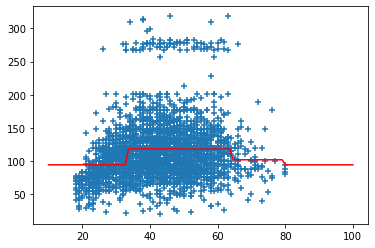

In [38]:
##ANSWER##
bin_mapping = np.digitize(t, bins)

bin_mapping
t_dummies = pd.get_dummies(bin_mapping)
t_dummies = t_dummies.drop(columns =[0,1,5])

stepPredict = clf.predict(t_dummies)


plt.scatter(df.age,df.wage,marker = '+')

plt.plot(t,stepPredict,color='red')

&#9989; **<font color=red>Do this:</font>** If there's time, modify your code to do classification and recreate the plot on the right side of Fig 7.2.

In [39]:
# Your code here #

# 2. Splines 

Next, we'll build some spline models. Let's start by playing with some toy data, making heavy use of the examples provided on the [scikitlearn spline page](https://scikit-learn.org/stable/auto_examples/linear_model/plot_polynomial_interpolation.html).

In [40]:
# Note: this bit is going to use some packages that are newly 
# provided in sklearn 1.0.  If you're having issues, try uncommenting
# and running the update line below.
# pip install --upgrade scikit-learn

In [41]:
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline

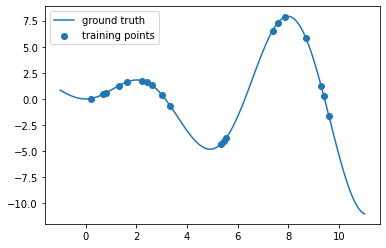

In [42]:
# This code block is going to make us some nasty fake data 
# to try to find some sort of interpolation. 

def f(x):
    """Function to be approximated by polynomial interpolation."""
    return x * np.sin(x)


# whole range we want to plot
x_plot = np.linspace(-1, 11, 100)
y_plot = f(x_plot)


# Make some data.  Provide a small amount of points to make 
# our polynomials all kinds of wiggly.
X = np.linspace(0, 10, 100)
rng = np.random.RandomState(0)
X = np.sort(rng.choice(X, size=20, replace=False))
y = f(X)

# # create 2D-array versions of these arrays to feed to transformers
# X_train = x_train[:, np.newaxis]
# X = X[:, np.newaxis]

X = X.reshape(-1,1)
y = y.reshape(-1,1)


#====ploting======

# plot function
plt.plot(x_plot, y_plot,label="ground truth")

# plot training points
plt.scatter(X, y, label="training points")

plt.legend()

Let's pretend you never saw that $f$ function I used to build the data, you're just handed these scattered data points and asked to learn a piecewise polynomial that fits it. 

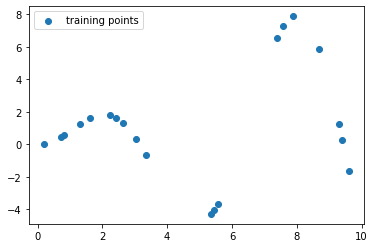

In [43]:
# plot training points
plt.scatter(X, y, label="training points")

plt.legend()

The `SplineTransformer` sets up our basis functions for us. These are the functions that we are learning coefficients for when we are doing regression.

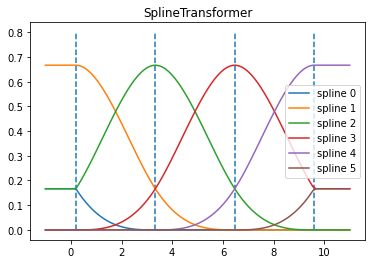

In [44]:
ax = plt.gca()
splt = SplineTransformer(n_knots=4, degree=3).fit(X)
ax.plot(x_plot, splt.transform(x_plot.reshape(-1,1)))
ax.legend(ax.lines, [f"spline {n}" for n in range(6)])
ax.set_title("SplineTransformer")

# plot knots of spline
knots = splt.bsplines_[0].t
ax.vlines(knots[3:-3], ymin=0, ymax=0.8, linestyles="dashed")


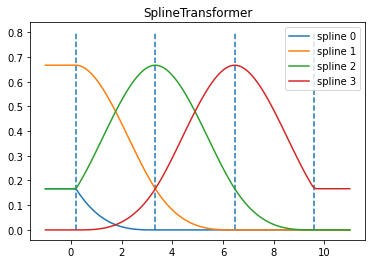

In [49]:
##ANSWER##

# Making a figure for slides 

ax = plt.gca()
splt = SplineTransformer(n_knots=4, degree=3).fit(X)
F = splt.transform(x_plot.reshape(-1,1))
maxN = 4
ax.plot(x_plot, F[:,:maxN])
ax.legend(ax.lines, [f"spline {n}" for n in range(maxN)])
ax.set_title("SplineTransformer")

# plot knots of spline
knots = splt.bsplines_[0].t
ax.vlines(knots[3:-3], ymin=0, ymax=0.8, linestyles="dashed")


I'm going to make use of a nice function from scikitlearn that builds up a pipeline for us to use.  Basically, the `make_pipline` function here takes your input data, runs the `SplineTransformer` on it to get the features, then runs `Ridge` regression.  

In [52]:
# B-spline with 4 + 3 - 1 = 6 basis functions
model = make_pipeline(SplineTransformer(n_knots=4, degree=3), LinearRegression())
model.fit(X, y)


y_hat = model.predict(X)


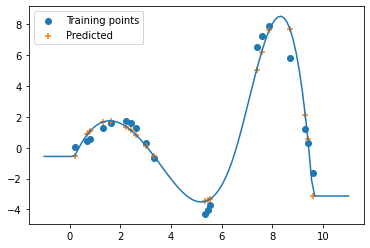

In [55]:
spline_y_plot = model.predict(x_plot.reshape(-1,1))


# plot training points
plt.scatter(X, y, label="Training points")

plt.scatter(X,y_hat,label = 'Predicted',marker = '+')

plt.legend()


plt.plot(x_plot,spline_y_plot)

&#9989; **<font color=red>Do this:</font>** 
- Using the code above that generates splines, build a cubic spline model to predict wage from age. 
- Use your trained model to draw the learned spline on the scatter plot of age and wage, as in the left side of Fig 7.5. (*Note we're only doing regular splines with this code, not natural as in Fig 7.4, but the results end up pretty similar in our case*)

In [56]:
# Your code here #

In [57]:
##ANSWER##

X = np.array(df.age).reshape(-1,1)
y = np.array(df.wage).reshape(-1,1)

print(X.shape)

model = make_pipeline(SplineTransformer(n_knots=4, degree=3), LinearRegression())
model.fit(X,y)

(3000, 1)


Pipeline(steps=[('splinetransformer', SplineTransformer(n_knots=4)),
                ('linearregression', LinearRegression())])

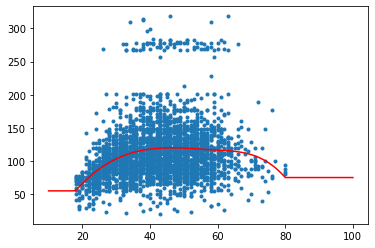

In [58]:
##ANSWER##


plt.scatter(df.age,df.wage,marker = '.')
y_spline = model.predict(t.reshape(-1,1))
plt.plot(t,y_spline,color = 'red')

# 3. GAMs

Our last trick is to build up some generalized linear models (GAMs) by combining our non-linear tools together for different input variables. 

Rather than doing this fully manually (which we could do by aplying our functions to each column and passing the result along to our favorite modeling tool), I'm going to make use of a nice package, `pygam`, which puts these things together for me. 

- [pygam documentation](https://pygam.readthedocs.io)
- [Quick start guide](https://pygam.readthedocs.io/en/latest/notebooks/quick_start.html)

In [77]:
# Uncomment here to install the pygam package. 
# pip install pygam

from pygam import LinearGAM, s, f

In [78]:
# I want to predict using three of my input variables
df_gam = df[['year','age','education']]
df_gam.head()

,year,age,education
231655,2006,18,1. < HS Grad
86582,2004,24,4. College Grad
161300,2003,45,3. Some College
155159,2003,43,4. College Grad
11443,2005,50,2. HS Grad


However, pygam inputs require numpy arrays, which require no columns of strings like our `education` data. I'm going to cheat and let pygam do my data cleanup for me. They need a numpy array rather than a dataframe. This version of the $X$ matrix has just converted our education entries into 0 through 3 (Wheee python numbering system!). 

In [80]:
from pygam.datasets import wage

X, y = wage()

X[:10,:]

array([[2.006e+03, 1.800e+01, 0.000e+00],
       [2.004e+03, 2.400e+01, 3.000e+00],
       [2.003e+03, 4.500e+01, 2.000e+00],
       [2.003e+03, 4.300e+01, 3.000e+00],
       [2.005e+03, 5.000e+01, 1.000e+00],
       [2.008e+03, 5.400e+01, 3.000e+00],
       [2.009e+03, 4.400e+01, 2.000e+00],
       [2.008e+03, 3.000e+01, 2.000e+00],
       [2.006e+03, 4.100e+01, 2.000e+00],
       [2.004e+03, 5.200e+01, 1.000e+00]])

This package has several nice built in tricks, that essentially recreate some of the work we did above.  

Namely, the tersely named `s` function builds a spline on the features its handed, and the also tersely named `f` function takes in factors (so does our dummy variable trick). 

In [84]:
from pygam import LinearGAM, s, f

gam = LinearGAM(s(0,n_splines = 4) + s(1,n_splines = 4) + f(2)).fit(X, y)

In [83]:
gam.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     25.1911
Link Function:                     IdentityLink Log Likelihood:                                -24118.6847
Number of Samples:                         3000 AIC:                                            48289.7516
                                                AICc:                                           48290.2307
                                                GCV:                                             1255.6902
                                                Scale:                                           1236.7251
                                                Pseudo R-Squared:                                   0.2955
Feature Function                  Lam

<ipython-input-83-dec6a6acdaaa>:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


Welcome to the fun of open source code! They put in a warning that there's a known bug, so the p-values are not to be trusted. The deeper you get in this world, the more interesting these errors become. Then you start contributing to try to fix them, and slowly everything becomes more and more stable. 

In any case, they have some built in code to recreate the plots like those you see in Fig 7.12 where we can see the predicted values and the confidence intervals

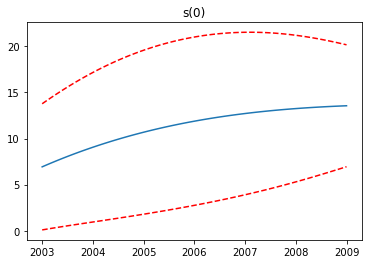

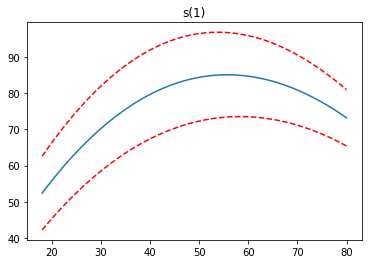

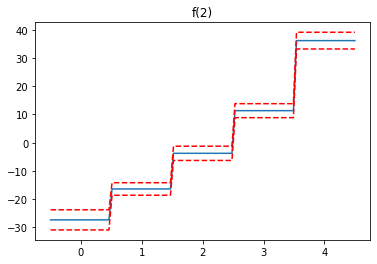

In [86]:
for i, term in enumerate(gam.terms):
    if term.isintercept:
        continue

    XX = gam.generate_X_grid(term=i)
    pdep, confi = gam.partial_dependence(term=i, X=XX, width=0.95)

    plt.figure()
    plt.plot(XX[:, term.feature], pdep)
    plt.plot(XX[:, term.feature], confi, c='r', ls='--')
    plt.title(repr(term))
    plt.show()

&#9989; **<font color=red>Do this:</font>** The function `LogisticGAM` from the `pygam` package does classification. Use this to modify the code above to build a GAM to predict whether a person will have income above $250. See if you can recreate Fig 7.13 and/or 7.14.

*By way of warning, my results aren't giving exactly the same functions as in the figures, but you should be able to get relatively close*

In [93]:
# Your code here #

In [94]:
##ANSWER##

from pygam import LogisticGAM, s, f

gam = LogisticGAM(s(0) + s(1) + f(2)).fit(X, y>250)

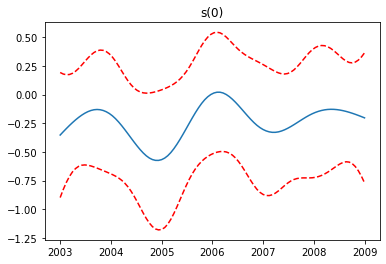

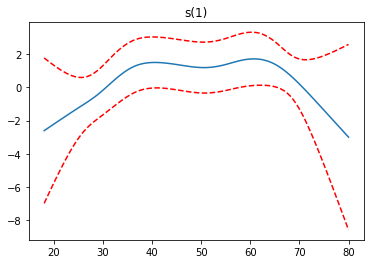

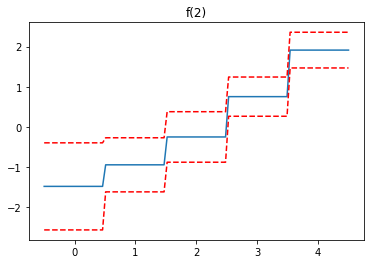

In [95]:
##ANSWER##
for i, term in enumerate(gam.terms):
    if term.isintercept:
        continue

    XX = gam.generate_X_grid(term=i)
    pdep, confi = gam.partial_dependence(term=i, X=XX, width=0.95)

    plt.figure()
    plt.plot(XX[:, term.feature], pdep)
    plt.plot(XX[:, term.feature], confi, c='r', ls='--')
    plt.title(repr(term))
    plt.show()

# Lab Survey

To get credit for today's lab, fill out the following survey before the end of class:

https://forms.gle/hX8GT5FJ2fNMeTo1A

Note this is the same link for every lab, so you will fill this out multiple times this semester.



-----
### Congratulations, we're done!
Written by Dr. Liz Munch, Michigan State University

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.

In [96]:
##ANSWER## 
# This cell gets the name of the current notebook. Needs a sec
# to run before it works

from jupyterinstruct import InstructorNotebook
this_notebook = InstructorNotebook.getname()


##ANSWER## 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [99]:
##ANSWER##
#This cell runs the converter which removes ANSWER fields, renames the notebook and cleans out output fields. 

studentnotebook = InstructorNotebook.makestudent(this_notebook)
InstructorNotebook.validate(studentnotebook)

Myfilename Lab-Ch7-Part3-Nonlinear-INSTRUCTOR.ipynb


Lab-Ch7_Part3_Nonlinear.ipynb


Validating Notebook ./Lab-Ch7_Part3_Nonlinear.ipynb
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..


7